In [41]:
import random
import matplotlib.pyplot as plt
from matplotlib.cm import ScalarMappable
from matplotlib.colors import LinearSegmentedColormap, Normalize
import igraph as ig

import pandas as pd
import numpy as np
import os
import math
import re
from collections import Counter
import scipy.stats
import seaborn as sns
from matplotlib.font_manager import FontProperties  # 导入FontProperties
import warnings
warnings.filterwarnings("ignore")

import networkx as nx

In [42]:
path1 = r'E:\netData\APS\1 Authors\APS_authorsDCCC2.0.zip'

In [43]:
f1 = pd.read_csv(path1)

In [44]:
f1['type'] = f1['type'].map(dict(zip(['获奖学者','非获奖学者'] , ['laureate' , 'non laureate'])))

In [45]:
f1.head(3)

,au,pub,pub_num,hcore,h,tc,DChore,CChore,DC,CC,dh,ch,auu,type
0,p. bassi,"['10.1103/PhysRevE.71.056608', '10.1103/PhysRe...",4,"[1, 12, 3, 41]",3,57,"[0, 10, 1, 7]","[1, 2, 2, 34]",18,39,2,2,p.bassi,non laureate
1,cl. gabriel,"['10.1103/PhysRevD.63.024010', '10.1103/PhysRe...",4,"[0, 1, 12, 2]",2,15,"[0, 0, 0, 0]","[0, 1, 12, 2]",0,15,0,2,cl.gabriel,non laureate
2,m. j. norgett,['10.1103/PhysRevB.18.2739'],1,[14],1,14,[5],[9],5,9,1,1,m.j.norgett,non laureate


In [46]:
def get_IR(threshold , v , f1):
    k = int(np.floor(len(f1)*threshold))
    f2 = f1.sort_values([v],ascending= False)
    f21 = f2.head(k)
    d = len(f21[f21['type']=='laureate'])/130
    return d

In [47]:
thresholdlst = [0.001,0.005,0.01,0.02,0.05]

In [48]:
threshold = 0.01
vlst = ['pub_num','h','tc','DC','CC','dh','ch']

In [49]:
dlst = [get_IR(threshold , v , f1) for v in vlst]

In [50]:
dlst

[0.2846153846153846,
 0.5307692307692308,
 0.5615384615384615,
 0.6538461538461539,
 0.45384615384615384,
 0.6230769230769231,
 0.4461538461538462]

In [51]:
def draw_bar(dlst , path , label):
    f, ax = plt.subplots(figsize=(7, 7))
    c = ['#6E2C00','#A04000','#BA4A00','#154360','#0B5345','#21618C','#196F3D']
    y_pos = [1,2,3,4,5,6,7]

    plt.barh(y_pos,dlst,align='center', color= c,alpha=0.9,capsize=10)

    plt.yticks(y_pos,['publications','h-index','total citations','SDC','SCC','D h-index','C h-index'],fontsize = 20)

    plt.xticks(fontsize=20)
    plt.xlabel('IR',fontsize = 25)
    plt.title('IR z={}'.format(label),fontsize = 30)
    
    ax.vlines(dlst[3],0,8, linestyles='dashed',colors = '#154360')

    plt.savefig("F:/目前研究项目/APS分析/SCIENTOMETRICS SDC SCC/fig/fig 4/{}.pdf".format(path),bbox_inches = 'tight')

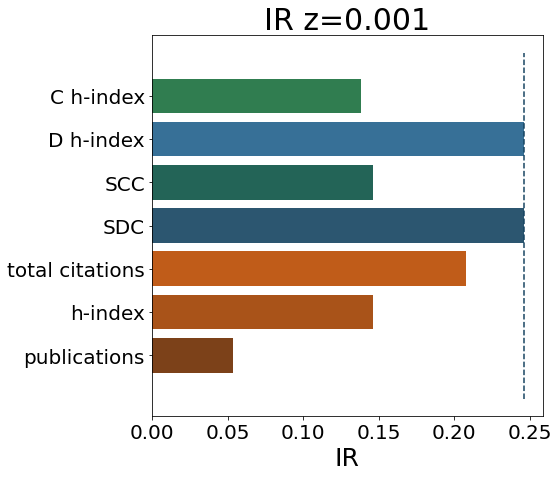

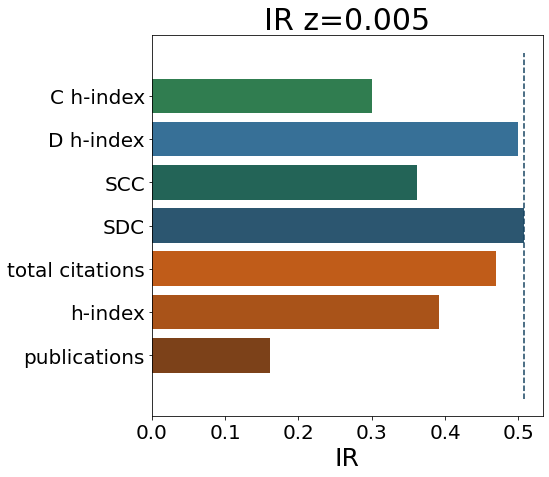

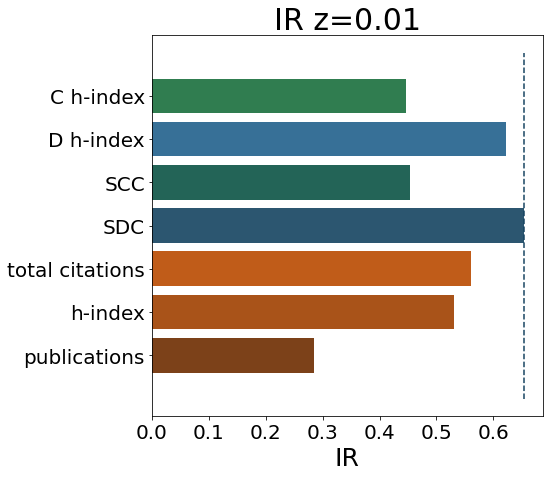

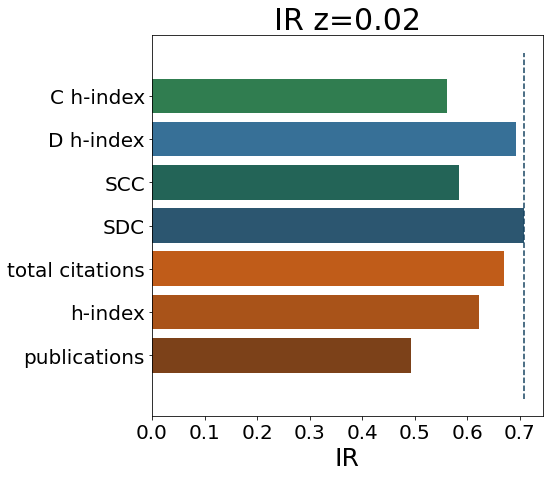

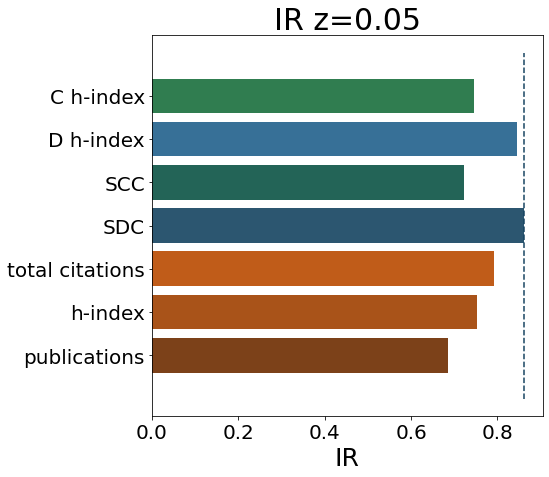

In [25]:
for i in range(len(thresholdlst)):
    threshold = thresholdlst[i]
    path = i
    label = str(threshold)
    dlst = [get_IR(threshold , v , f1) for v in vlst]
    draw_bar(dlst , path , label)

# AR

In [38]:
def get_AR( v , f1):
    f2 = f1.sort_values([v],ascending= False)
    f2.index = range(len(f2))
    lst = f2[f2['type']=='laureate'].index
    d = sum(lst)/(lst[-1] - lst[0])/len(lst)
    return d

In [39]:
dlst = [get_AR(v , f1) for v in vlst]

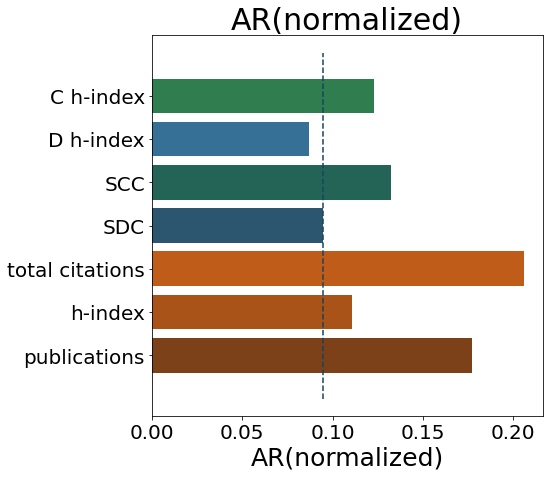

In [40]:
f, ax = plt.subplots(figsize=(7, 7))
c = ['#6E2C00','#A04000','#BA4A00','#154360','#0B5345','#21618C','#196F3D']
y_pos = [1,2,3,4,5,6,7]

plt.barh(y_pos,dlst,align='center', color= c,alpha=0.9,capsize=10)

plt.yticks(y_pos,['publications','h-index','total citations','SDC','SCC','D h-index','C h-index'],fontsize = 20)

plt.xticks([0,0.05,0.10,0.15,0.20],fontsize=20,)
plt.xlabel(r'AR(normalized)',fontsize = 25)
plt.title(r'AR(normalized)',fontsize = 30)
ax.vlines(dlst[3],0,8, linestyles='dashed',colors = '#154360')
plt.savefig("F:/目前研究项目/APS分析/SCIENTOMETRICS SDC SCC/fig/fig 4/AR1.pdf".format(path),bbox_inches = 'tight')

In [32]:
def get_AR( v , f1):
    f2 = f1.sort_values([v],ascending= False)
    f2.index = range(len(f2))
    lst = f2[f2['type']=='laureate'].index
    d = sum(lst)/len(lst)
    return d

In [33]:
dlst = [get_AR(v , f1) for v in vlst]

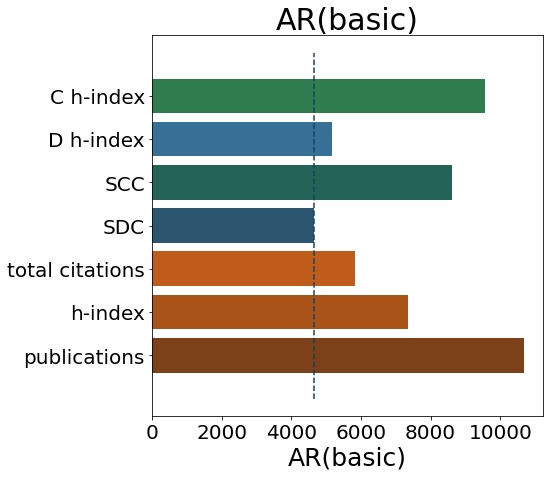

In [37]:
f, ax = plt.subplots(figsize=(7, 7))
c = ['#6E2C00','#A04000','#BA4A00','#154360','#0B5345','#21618C','#196F3D']
y_pos = [1,2,3,4,5,6,7]

plt.barh(y_pos,dlst,align='center', color= c,alpha=0.9,capsize=10)

plt.yticks(y_pos,['publications','h-index','total citations','SDC','SCC','D h-index','C h-index'],fontsize = 20)

plt.xticks(fontsize=20,)
plt.xlabel(r'AR(basic)',fontsize = 25)
plt.title(r'AR(basic)',fontsize = 30)
ax.vlines(dlst[3],0,8, linestyles='dashed',colors = '#154360')
plt.savefig("F:/目前研究项目/APS分析/SCIENTOMETRICS SDC SCC/fig/fig 4/AR2.pdf".format(path),bbox_inches = 'tight')